Saving 7. Predict Credit Card Fraud.csv to 7. Predict Credit Card Fraud (3).csv
Shape: (284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64
Accuracy: 0.9995962220427653

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



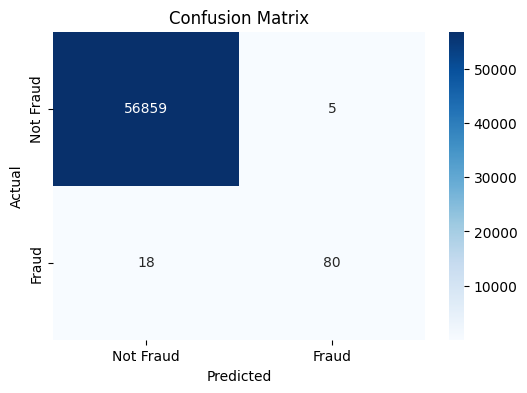

In [3]:
# STEP 1: INSTALL & IMPORT LIBRARIES
!pip install -q matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# STEP 2: LOAD THE DATA (UPLOAD IN COLAB)
from google.colab import files
uploaded = files.upload()

# After upload, read the file (adjust filename if needed)
df = pd.read_csv("7. Predict Credit Card Fraud.csv")

# STEP 3: BASIC INFO
print("Shape:", df.shape)
print(df["Class"].value_counts())  # 0 = normal, 1 = fraud
df.head()

# STEP 4: SEPARATE FEATURES AND TARGET
X = df.drop("Class", axis=1)
y = df["Class"]

# STEP 5: TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# STEP 6: TRAIN RANDOM FOREST CLASSIFIER
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# STEP 7: MAKE PREDICTIONS
y_pred = model.predict(X_test)

# STEP 8: EVALUATE MODEL
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# STEP 9: PLOT CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Not Fraud", "Fraud"], yticklabels=["Not Fraud", "Fraud"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
